## Module 5 - Machine Learning
### Unit 3 - Correlation and Regression experimentation

In this file, we're generating 2 variables with a finite set of numbers.
The two together follow a simple linear regression function:

$\hat{y}=b_{0}+b_{1}x$

We use these variables to plot the slop, intercept and Pearson r.
We also use them to create a prediction using a linear regression model.

The first version includes completely random numbers, and we get:
- This formula with the slope and intercept is: $\hat{y} = 103.106 - 1.751X$
- A negative Pearson correlation (also known as Pearson's r) of -0.759
- The standard error is 0.45, with most dots relatively close to the linear line

In [29]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
%matplotlib inline

Slope: -1.7512877115526118
Intercept: 103.10596026490066
p-value: 0.0026468739224561077
Standard error: 0.453536157607742
Pearsons correlation: -0.759
mean_x: 7.615384615384615 mean_y: 89.76923076923077


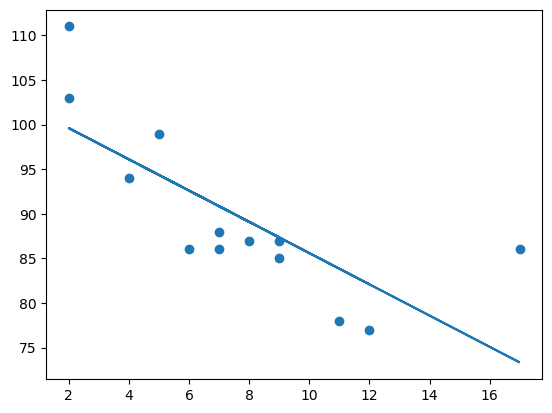

In [18]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Slope:", slope)
print("Intercept:", intercept)
print("p-value:", p)
print("Standard error:", std_err)

# measure the correlation 
corr, _ = stats.pearsonr(x, y)
print('Pearsons correlation: %.3f' % corr)
mean_x = np.mean(x)
mean_y = np.mean(y)
print("mean_x:", mean_x, "mean_y:", mean_y)
    
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()


## Predict Future Values

In [22]:
from scipy import stats

x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return intercept + slope * x 

speed = myfunc(10)

print(speed)

85.59308314937454


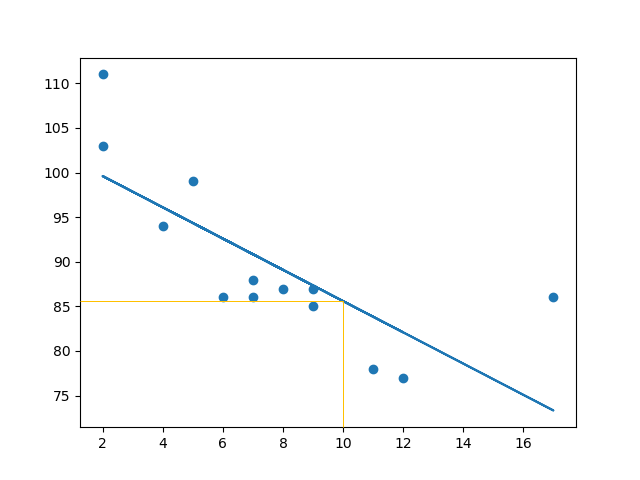

If x=10 then predicted y is 85.59

### Manipulation 1 - Introducing more outliers in the data

In this manipulation, we've changed 2 numbers in y, creating a new variable, y_outliers.
We've added a high-value outlier: 250, and a low-value outlier: 5.
The result is:
- The linear line is more horizontal, trying to fit the outlier values
- The standard error is larger - increased from 0.45 to 3.627
- p=0.32>α=0.05, so the linear relationship is no longer statistically significant. We don't have sufficient evidence to reject the null hypothesis that the true slope is zero.
- We see clearly the two outliers as dots that are far from the linear line
- The y prediction for x=10 is not far off the original prediction before the manipulation (from 85.6 to 87.8). However, that does not mean the model overall has been unaffected.

**In Summary:**

The two extreme outliers led to the regression line becoming flatter, as it tries to account for the extreme values of the outliers. Pearson's correlation weakens, the uncertainty around the estimated slope increases, and the relationship is no longer statistically significant.

Slope: -3.7380426784400296
Intercept: 125.15894039735099
p-value: 0.3249151294010727
Standard error: 3.6275137938269264
Pearsons correlation: -0.297
mean_x: 7.615384615384615 mean_y: 96.6923076923077


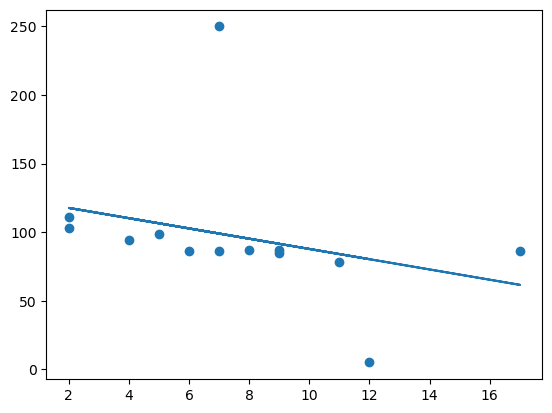

In [19]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y_outliers = [99,86,87,250,111,86,103,87,94,78,5,85,86]

#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y_outliers)
print("Slope:", slope)
print("Intercept:", intercept)
print("p-value:", p)
print("Standard error:", std_err)

# measure the correlation 
corr, _ = stats.pearsonr(x, y_outliers)
print('Pearsons correlation: %.3f' % corr)
mean_x = np.mean(x)
mean_y_outliers = np.mean(y_outliers)
print("mean_x:", mean_x, "mean_y:", mean_y_outliers)
    
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y_outliers)
plt.plot(x, mymodel)
plt.show()


In [25]:
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y_outliers = [99,86,87,250,111,86,103,87,94,78,5,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y_outliers)

def myfunc(x):
  return intercept + slope * x 

speed = myfunc(10)

print(speed)

87.77851361295069


### Manipulation 2 - Add a lot of noise

By creating a new variable called y_noisy and populating it with values that do not correspond with the direction of the corresponding values in x.

What we get is:
- The regression line becomes flatter as it minimizes the sum of squared residuals across all observations.
- The points are widely scattered around the line with no strong linear pattern
- The standard error is 1.8, which is less than the one we got with the big outliers, but more than the original set of values
- p=0.179>α=0.05, so the linear relationship is no longer statistically significant. We don't have sufficient evidence to reject the null hypothesis that the true slope is zero.

**In summary:**

The new values introduce considerably more noise into the relationship between X and Y. As a result, the regression line becomes flatter, Pearson's correlation weakens, the uncertainty around the estimated slope increases, and the relationship is no longer statistically significant.


Slope: -2.435246504782928
Intercept: 121.31456953642385
p-value: 0.1795556028437033
Standard error: 1.698955771029734
Pearsons correlation: -0.397
mean_x: 7.615384615384615 mean_y: 102.76923076923077


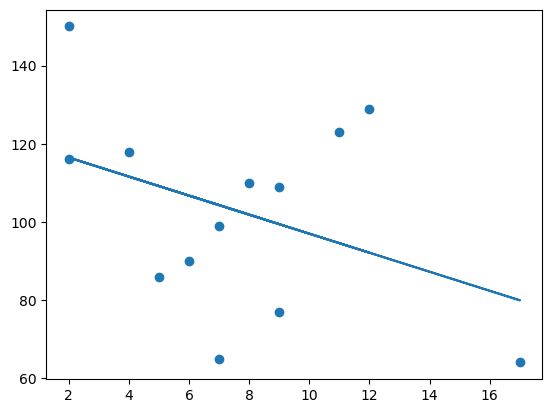

96.96210448859456


In [32]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y_noisy = [86,99,110,65,150,64,116,77,118,123,129,109,90]

#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y_noisy)
print("Slope:", slope)
print("Intercept:", intercept)
print("p-value:", p)
print("Standard error:", std_err)

# measure the correlation 
corr, _ = stats.pearsonr(x, y_noisy)
print('Pearsons correlation: %.3f' % corr)
mean_x = np.mean(x)
mean_y_noisy = np.mean(y_noisy)
print("mean_x:", mean_x, "mean_y:", mean_y_noisy)
    
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y_noisy)
plt.plot(x, mymodel)
plt.show()

speed = myfunc(10)

print(speed)

### Manipulation 3 - More closely correlated
By creating a new variable called y_closer and populating it with values that align more closely to the direction of the corresponding values in the x variable, we can see how the regression is affected:
- The negative correlation is maintained and strengthened.
- The regression line is perfectly aligned with all data points, with Pearson's correlation at −1, indicating a perfect negative linear relationship.
- The residuals are zero (or effectively zero due to numerical precision), because every observed value lies exactly on the regression line.
- The standard error of the slope is zero (or effectively zero), because there is no uncertainty in the estimated linear relationship in this dataset.
- The p-value is extremely close to zero, indicating very strong evidence against the null hypothesis of no linear relationship.

**In Summary:**

Aligning the numbers more closely led to the linear line becoming steeper and Pearson's correlation reaching -1, indicating perfect linearity. This is supported by the close-to-zero standard error and p-value that provide additional evidence.

Slope: -4.999999999999998
Intercept: 129.99999999999997
p-value: 7.962449841452219e-85
Standard error: 3.890938817464512e-08
Pearsons correlation: -1.000
mean_x: 7.615384615384615 mean_y: 91.92307692307692


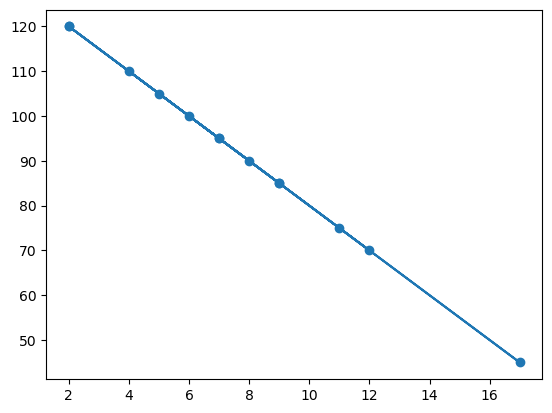

79.99999999999999


In [30]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y_closer = [105, 95, 90, 95, 120, 45, 120, 85, 110, 75, 70, 85, 100]

#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y_closer)
print("Slope:", slope)
print("Intercept:", intercept)
print("p-value:", p)
print("Standard error:", std_err)

# measure the correlation 
corr, _ = stats.pearsonr(x, y_closer)
print('Pearsons correlation: %.3f' % corr)
mean_x = np.mean(x)
mean_y_closer = np.mean(y_closer)
print("mean_x:", mean_x, "mean_y:", mean_y_closer)
    
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y_closer)
plt.plot(x, mymodel)
plt.show()

speed = myfunc(10)

print(speed)